In [530]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC 
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score

In [531]:
df = pd.read_csv('T:\Python\SP24\AIL\Data\wine-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [532]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [533]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [534]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [535]:
df.duplicated().sum()

240

In [536]:
# df.drop_duplicates(inplace=True)
# df.reset_index(inplace=True, drop=True)
# df

In [537]:
df.quality.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [538]:
df.quality.value_counts()/len(df)*100

quality
5    42.589118
6    39.899937
7    12.445278
4     3.314572
8     1.125704
3     0.625391
Name: count, dtype: float64

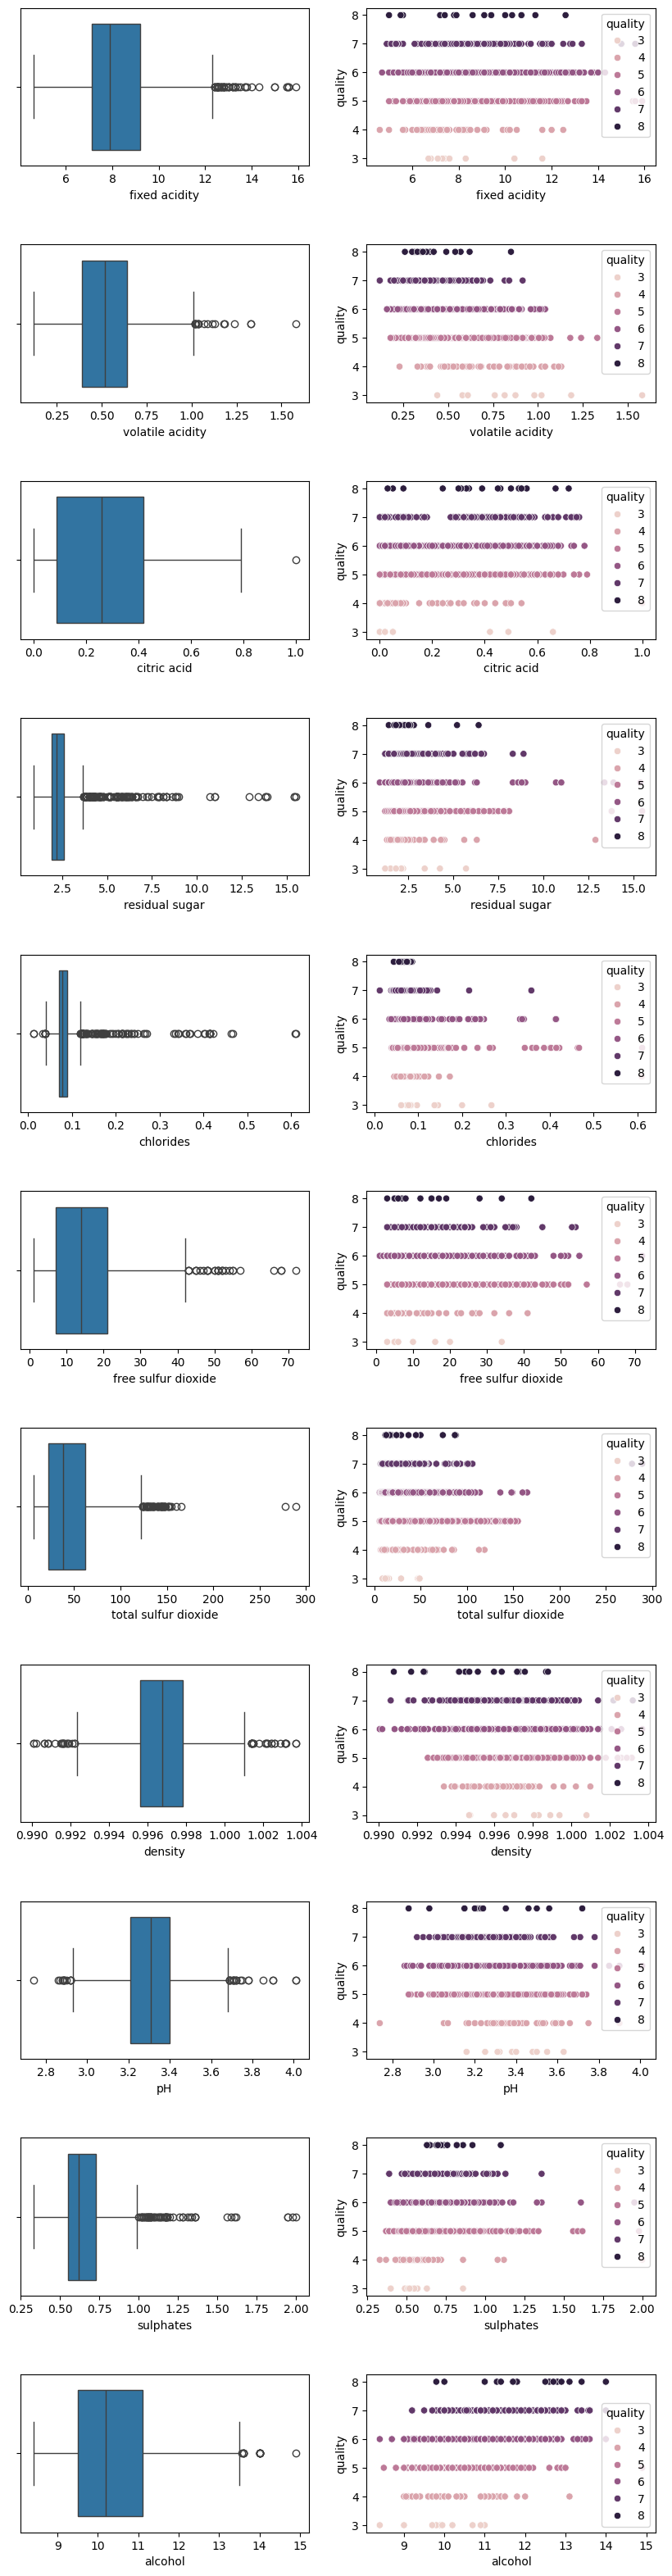

In [539]:
columns = list(df.columns)
fig, ax = plt.subplots(11, 2, figsize=(10,40))
plt.subplots_adjust(hspace = 0.5)
for i in range(11) :
    sns.boxplot(x=columns[i], data=df, ax=ax[i, 0])
    
    sns.scatterplot(x=columns[i], y='quality', data=df, hue='quality', ax=ax[i, 1])

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

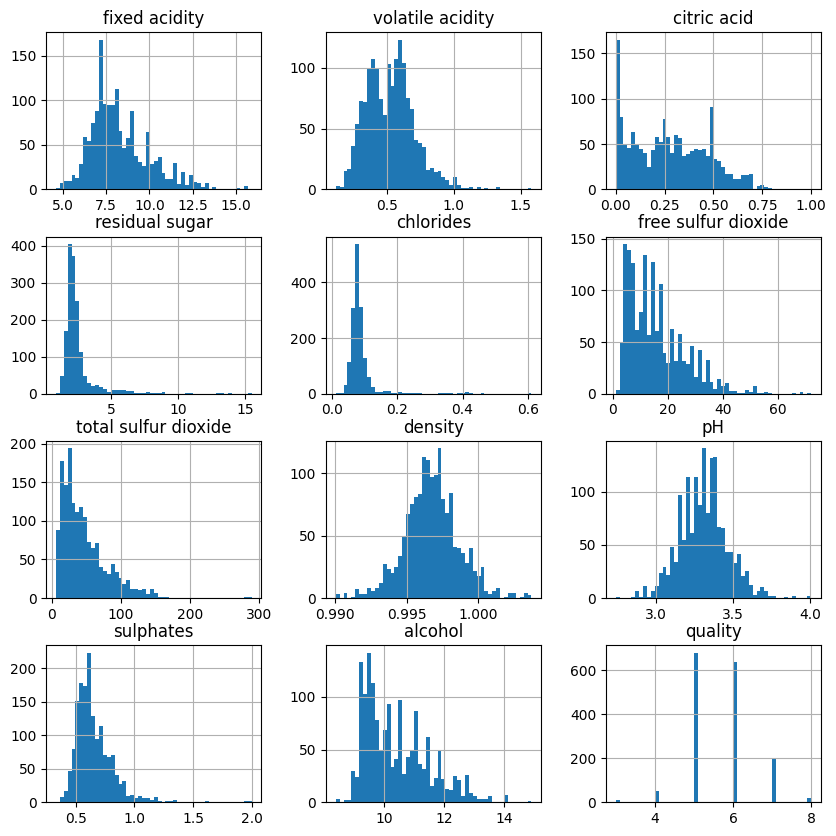

In [540]:
df.hist(figsize=(10,10), bins=50)

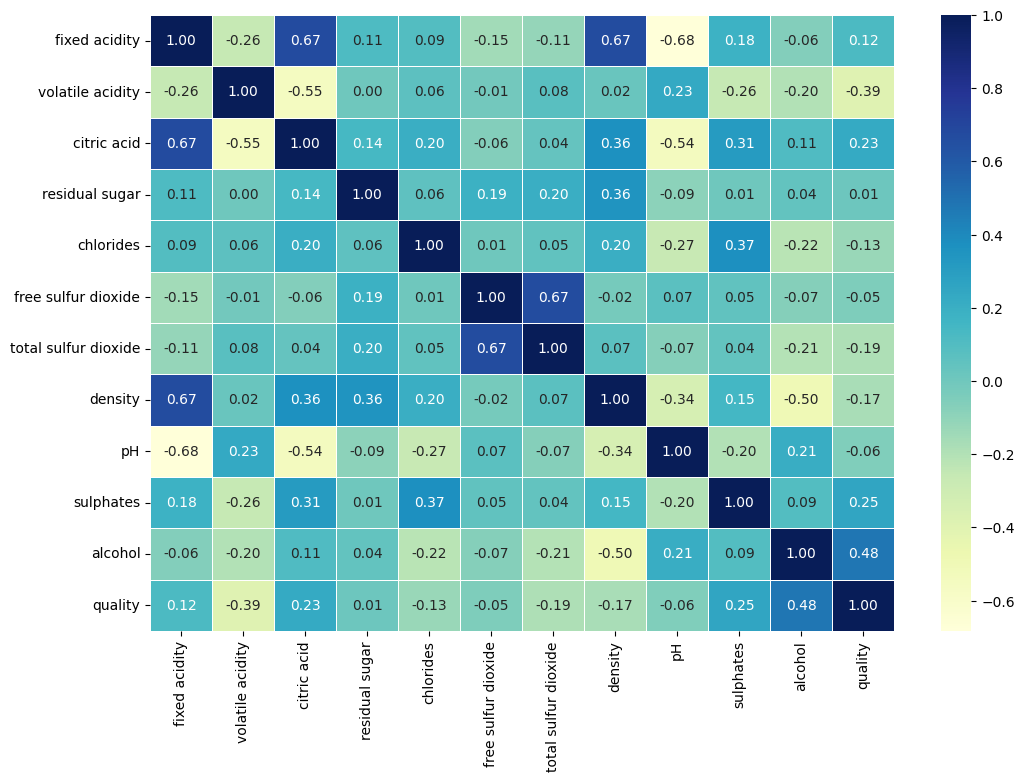

In [541]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='YlGnBu', annot = True, fmt=".2f", linewidths=0.5)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24764\1869632926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


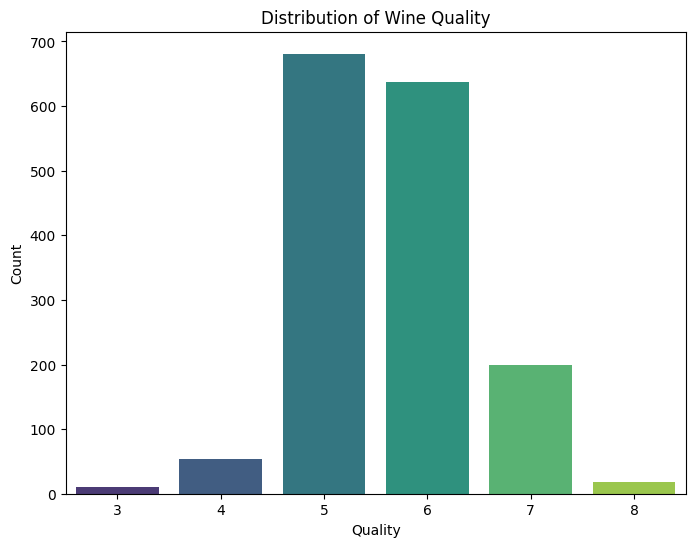

Class Distribution:
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [542]:
class_counts = df['quality'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

print("Class Distribution:")
print(class_counts)

### we can check and see that class 3,4,8 in quality have lower values, it can lead to imbalanced data, so we can remove that to increase the performance, this is one way to handle imbalanced data

In [543]:
df = df.drop(df[df['quality'] == 3].index)
df = df.drop(df[df['quality'] == 4].index)
df = df.drop(df[df['quality'] == 8].index)
df.reset_index(inplace=True, drop=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1513,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1514,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1515,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1516,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [544]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
Name: count, dtype: int64

### after drop class 3,4,8, we will resample the data for class 5,6,7. In this case we will apply upresample for 2 class 6,7 to be equal to class 5

In [545]:
df_majority = df[(df['quality']==5)] 
df_minority_1 = df[(df['quality']==6)] 
df_minority_2 = df[(df['quality']==7)] 

df_minority_upsampled_1 = resample(df_minority_1, 
                                 replace=True,    
                                 n_samples= 577, 
                                 random_state=42)  
df_minority_upsampled_2 = resample(df_minority_2, 
                                 replace=True,    
                                 n_samples= 577, 
                                 random_state=42) 

df_upsampled = pd.concat([df_minority_upsampled_1, df_minority_upsampled_2, df_majority])

In [546]:
df_upsampled['quality'].value_counts()

quality
5    681
6    577
7    577
Name: count, dtype: int64

In [547]:
X_train,X_test, y_train, y_test = train_test_split(df_upsampled.iloc[:, :-1], df_upsampled.iloc[:,-1], test_size=0.33, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [548]:
lr_classificate = LogisticRegression()
lr_classificate.fit(X_train, y_train)

y_pred = lr_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.6241082078495569
Recall: 0.6353135313531353
F1-score: 0.6277108520847857
Accuracy: 63.53%


In [549]:
knn_classificate = KNeighborsClassifier()
knn_classificate.fit(X_train, y_train)

y_pred = knn_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.6801942545799475
Recall: 0.6798679867986799
F1-score: 0.6775570319639151
Accuracy: 67.99%


In [550]:
svc_classificate = SVC()

svc_classificate.fit(X_train, y_train)

y_pred = svc_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.716316484528982
Recall: 0.7161716171617162
F1-score: 0.7156054203243816
Accuracy: 71.62%


In [551]:
rf_classificate = RandomForestClassifier()
rf_classificate.fit(X_train, y_train)

y_pred = rf_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.8883838123864785
Recall: 0.8877887788778878
F1-score: 0.8876449641887196
Accuracy: 88.78%


In [552]:
et_classificate = ExtraTreesClassifier()
et_classificate.fit(X_train, y_train)

y_pred = et_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.8705049361343562
Recall: 0.8696369636963697
F1-score: 0.8699681085820666
Accuracy: 86.96%


In [553]:
dt_classificate = DecisionTreeClassifier()
dt_classificate.fit(X_train, y_train)

y_pred = dt_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.8372894772324058
Recall: 0.8366336633663366
F1-score: 0.834773688674302
Accuracy: 83.66%


In [554]:
ba_classificate = BaggingClassifier(dt_classificate)
ba_classificate.fit(X_train, y_train)

y_pred = ba_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.8636415296409038
Recall: 0.8646864686468647
F1-score: 0.8639456563180258
Accuracy: 86.47%


In [555]:
gb_classificate = GradientBoostingClassifier()
gb_classificate.fit(X_train, y_train)

y_pred = gb_classificate.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(accuracy * 100))

Precision: 0.8009820644101477
Recall: 0.8003300330033003
F1-score: 0.8005406539826169
Accuracy: 80.03%
